# Class 4: Vulnerability

## GIS Vulnerability & Risk Assessment Course

**Objective:** Understand how to combine Potential Impact and Adaptive Capacity into a single Vulnerability score using a lookup matrix.

## What is Vulnerability?

Vulnerability describes how susceptible something is to harm when exposed to a hazard.

**Key Formula:**
```
Vulnerability = Potential Impact × (1 / Adaptive Capacity)
```

Or more simply: **A location is vulnerable when:**
1. The potential impact of a hazard is HIGH, AND
2. The adaptive capacity (ability to cope, prepare, recover) is LOW

**Examples:**
- A flood-prone neighborhood with poor drainage and low-income residents = HIGH vulnerability
- A flood-prone neighborhood with excellent levees and well-resourced residents = LOWER vulnerability
- An earthquake-prone area with no building codes = HIGH vulnerability
- An earthquake-prone area with strict building codes = LOWER vulnerability

**In this class:** We'll use a simple lookup matrix to combine Potential Impact and Adaptive Capacity scores into a Vulnerability score.

In [4]:
!pip install geopandas fiona shapely pyproj requests folium seaborn contextily --quiet
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
All libraries loaded successfully!


## Step 1: Mount Your Google Drive

We'll store all data in Google Drive so you can access it anytime.

In [ ]:
# from google.colab import drive
drive.mount('/content/drive')

# Set the base directory where your GIS data is stored
BASE_DIR = '/content/drive/MyDrive/MSER_510_VULNERABILTY'
DATA_DIR = os.path.join(BASE_DIR, 'data')

# GeoPackage file paths for chained loading/saving
INPUT_GPKG = os.path.join(DATA_DIR, 'class_3_adaptive_capacity.gpkg')  # Load from Class 3
OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_4_vulnerability.gpkg')  # Save to Class 4
CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')  # Fallback for base layers

# Check if the input directory exists
if os.path.exists(BASE_DIR):
    print(f"✓ Successfully connected to: {BASE_DIR}")
    print("\nFiles in this directory:")
    for item in os.listdir(BASE_DIR):
        print(f"  - {item}")
else:
    print(f"⚠ Directory not found: {BASE_DIR}")
    print("Please check your Google Drive path and try again.")

### Optional: Run Locally Instead of Google Colab

If you prefer to run this notebook on your own machine (e.g., using Jupyter or VS Code) instead of Google Colab, comment out the Google Drive cell above and uncomment the cell below. Update the `BASE_DIR` path to point to a folder on your local filesystem.

In [ ]:
# LOCAL RUN: Uncomment the lines below to run locally instead of Google Colab
# Update the path to match your local folder

# import os

# BASE_DIR = './'
# DATA_DIR = os.path.join(BASE_DIR, 'data')
# OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')

# os.makedirs(DATA_DIR, exist_ok=True)
# os.makedirs(OUTPUT_DIR, exist_ok=True)

# INPUT_GPKG = os.path.join(DATA_DIR, 'class_3_adaptive_capacity.gpkg')
# OUTPUT_GPKG = os.path.join(DATA_DIR, 'class_4_vulnerability.gpkg')
# CLASS0_GPKG = os.path.join(DATA_DIR, 'vulnerability_risk_data.gpkg')

## Step 2: Understanding the Vulnerability Scoring Matrix

The **Vulnerability Scoring Matrix** is a simple lookup table that combines two factors:

| | **Potential Impact: Low (1)** | **Medium (2)** | **High (3)** |
|---|---|---|---|
| **Adaptive Capacity: Low (1)** | Medium (2) | High (3) | High (3) |
| **Adaptive Capacity: Medium (2)** | Low (1) | Medium (2) | High (3) |
| **Adaptive Capacity: High (3)** | Low (1) | Low (1) | Medium (2) |

**How to read it:**
1. Find your **Adaptive Capacity** value (1, 2, or 3) on the LEFT side
2. Find your **Potential Impact** value (1, 2, or 3) on the TOP
3. Where they intersect = your **Vulnerability** score

**Key insights:**
- **High Adaptive Capacity + Low Potential Impact = LOW Vulnerability** (best case!)
- **Low Adaptive Capacity + High Potential Impact = HIGH Vulnerability** (worst case)
- Adaptive Capacity matters! Even if impact is high, good preparedness reduces vulnerability.

### Visual Guide to the Matrix

Below is a color-coded version. **Dark cells = high vulnerability; light cells = low vulnerability.**

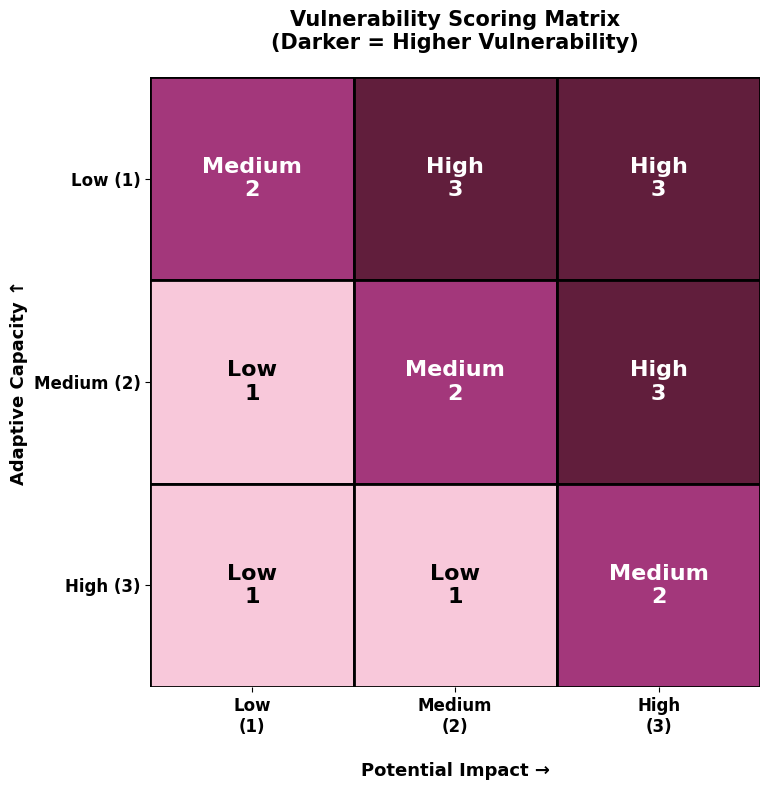

✓ Matrix visualization complete!


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Create the vulnerability matrix
# Format: matrix[adaptive_capacity_row, potential_impact_column]
# Where 0=index, 1=index, 2=index for values 1, 2, 3
vuln_matrix = np.array([
    [2, 3, 3],  # Row 0: Adaptive Capacity = Low (1)
    [1, 2, 3],  # Row 1: Adaptive Capacity = Medium (2)
    [1, 1, 2]   # Row 2: Adaptive Capacity = High (3)
])

# Color mapping using official symbology
# Vulnerability: 1 (Low)=#F8C8DA, 2 (Medium)=#A3377B, 3 (High)=#611E3C
colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}
text_colors = {1: 'black', 2: 'white', 3: 'white'}
labels = {1: 'Low\n1', 2: 'Medium\n2', 3: 'High\n3'}

# Create figure and axis
fig, ax = plt.subplots(figsize=(10, 8))

# Draw the matrix cells
for i in range(3):
    for j in range(3):
        val = vuln_matrix[i, j]
        # Draw rectangle
        ax.add_patch(plt.Rectangle((j, 2-i), 1, 1, facecolor=colors[val], edgecolor='black', linewidth=2))
        # Add text label
        ax.text(j+0.5, 2-i+0.5, labels[val], ha='center', va='center',
                fontsize=16, fontweight='bold', color=text_colors[val])

# Set axis limits and properties
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')

# Set tick labels
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['Low\n(1)', 'Medium\n(2)', 'High\n(3)'], fontsize=12, fontweight='bold')
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['High (3)', 'Medium (2)', 'Low (1)'], fontsize=12, fontweight='bold')

# Add axis labels
ax.set_xlabel('\nPotential Impact →', fontsize=13, fontweight='bold')
ax.set_ylabel('Adaptive Capacity ↑', fontsize=13, fontweight='bold')

# Add title
ax.set_title('Vulnerability Scoring Matrix\n(Darker = Higher Vulnerability)',
             fontsize=15, fontweight='bold', pad=20)

# Remove spines for cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print("✓ Matrix visualization complete!"
)

### Example: How to Read the Matrix

**Example 1: Area with Medium Adaptive Capacity & High Potential Impact**
- Adaptive Capacity = 2 (Medium) → Look at the MIDDLE row
- Potential Impact = 3 (High) → Look at the RIGHT column
- Intersection = **3 (High Vulnerability)**
- Interpretation: Even though the area has some adaptive capacity, the high impact of the hazard creates high overall vulnerability.

**Example 2: Area with High Adaptive Capacity & Low Potential Impact**
- Adaptive Capacity = 3 (High) → Look at the BOTTOM row
- Potential Impact = 1 (Low) → Look at the LEFT column
- Intersection = **1 (Low Vulnerability)**
- Interpretation: The area has good adaptive capacity AND the impact is limited, so vulnerability is low.

**Example 3: Area with Low Adaptive Capacity & Low Potential Impact**
- Adaptive Capacity = 1 (Low) → Look at the TOP row
- Potential Impact = 1 (Low) → Look at the LEFT column
- Intersection = **2 (Medium Vulnerability)**
- Interpretation: Even though the impact is low, the poor adaptive capacity means moderate vulnerability. This area still needs attention!

## Step 3: Load Your Parcels Data

We'll load parcels that already have **Potential Impact** and **Adaptive Capacity** scores from previous classes.

In [8]:
# Define the path to the GeoPackage (from Class 3)
gpkg_path = INPUT_GPKG

# Check if GeoPackage exists
if os.path.exists(gpkg_path):
    # List all layers in the GeoPackage
    import fiona
    layers = fiona.listlayers(gpkg_path)
    print(f"Layers in GeoPackage: {layers}")

    # Load the parcels layer
    parcels = gpd.read_file(gpkg_path, layer='parcels')
    print(f"\n✓ Successfully loaded parcels from Class 3!")
    print(f"Number of parcels: {len(parcels)}")
    print(f"\nColumns: {list(parcels.columns)}")
    print(f"\nFirst few rows:")
    print(parcels.head())
else:
    print(f"⚠ GeoPackage not found: {gpkg_path}")
    print("Attempting fallback from CLASS0_GPKG...")
    try:
        parcels = gpd.read_file(CLASS0_GPKG, layer='parcels')
        print(f"✓ Successfully loaded from fallback")
    except Exception as e:
        print(f"✗ Fallback also failed: {e}")

Layers in GeoPackage: ['flood_zones_100yr', 'study_area', 'flood_zones', 'buildings', 'parcels']

✓ Successfully loaded parcels from Class 3!
Number of parcels: 16078

Columns: ['objectid', 'parno', 'altparno', 'ownname', 'improvval', 'landval', 'parval', 'mailadd', 'munit', 'mcity', 'mstate', 'mzip', 'siteadd', 'sunit', 'scity', 'gisacres', 'struct', 'multistruc', 'saledate', 'saledatetx', 'legdecfull', 'parusecode', 'parusedesc', 'parusecd2', 'parusedsc2', 'parvaltype', 'owntype', 'recareano', 'recareatx', 'revisedate', 'sourceref', 'sourcedate', 'sourcedatx', 'subdivisio', 'nparno', 'cntyname', 'cntyfips', 'stfips', 'stcntyfips', 'gnisid', 'sourceagnt', 'transfdate', 'maddpref', 'maddrno', 'maddstname', 'maddstr', 'maddstsuf', 'maddsttyp', 'ownfrst', 'ownlast', 'revdatetx', 'reviseyear', 'saddno', 'saddpref', 'saddstname', 'saddstr', 'saddstsuf', 'saddsttyp', 'sstate', 'stname', 'subowntype', 'subsurfown', 'szip', 'structno', 'structyear', 'ownname2', 'presentval', 'mapref', 'st_are

### Verify Required Columns

We need **adaptive_capacity** and **potential_impact** columns to calculate vulnerability.

In [9]:
# Check if required columns exist
required_cols = ['adaptive_capacity', 'potential_impact']
missing_cols = [col for col in required_cols if col not in parcels.columns]

if missing_cols:
    print(f"⚠ Missing columns: {missing_cols}")
    print("\nAvailable columns:")
    print(parcels.columns.tolist())
else:
    print("✓ All required columns present!")
    print(f"\nAdaptive Capacity values: {sorted(parcels['adaptive_capacity'].unique())}")
    print(f"Potential Impact values: {sorted(parcels['potential_impact'].unique())}")

✓ All required columns present!

Adaptive Capacity values: [np.int64(1), np.int64(2), np.int64(3)]
Potential Impact values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


## Step 4: Calculate Vulnerability Scores

We'll use a **lookup dictionary** that implements the matrix. This dictionary takes a tuple of (adaptive_capacity, potential_impact) and returns the vulnerability score.

In [10]:
# Create the vulnerability matrix as a dictionary
# Key: (adaptive_capacity, potential_impact) → Value: vulnerability_score
vuln_lookup_matrix = {
    (1, 1): 2,  # Low AC, Low PI → Medium vulnerability
    (1, 2): 3,  # Low AC, Medium PI → High vulnerability
    (1, 3): 3,  # Low AC, High PI → High vulnerability
    (2, 1): 1,  # Medium AC, Low PI → Low vulnerability
    (2, 2): 2,  # Medium AC, Medium PI → Medium vulnerability
    (2, 3): 3,  # Medium AC, High PI → High vulnerability
    (3, 1): 1,  # High AC, Low PI → Low vulnerability
    (3, 2): 1,  # High AC, Medium PI → Low vulnerability
    (3, 3): 2,  # High AC, High PI → Medium vulnerability
}

print("Vulnerability Lookup Matrix:")
print("-" * 50)
for key, value in sorted(vuln_lookup_matrix.items()):
    ac, pi = key
    ac_label = ['Low', 'Medium', 'High'][ac - 1]
    pi_label = ['Low', 'Medium', 'High'][pi - 1]
    v_label = ['Low', 'Medium', 'High'][value - 1]
    print(f"AC={ac} ({ac_label:6s}), PI={pi} ({pi_label:6s}) → Vulnerability={value} ({v_label})")

Vulnerability Lookup Matrix:
--------------------------------------------------
AC=1 (Low   ), PI=1 (Low   ) → Vulnerability=2 (Medium)
AC=1 (Low   ), PI=2 (Medium) → Vulnerability=3 (High)
AC=1 (Low   ), PI=3 (High  ) → Vulnerability=3 (High)
AC=2 (Medium), PI=1 (Low   ) → Vulnerability=1 (Low)
AC=2 (Medium), PI=2 (Medium) → Vulnerability=2 (Medium)
AC=2 (Medium), PI=3 (High  ) → Vulnerability=3 (High)
AC=3 (High  ), PI=1 (Low   ) → Vulnerability=1 (Low)
AC=3 (High  ), PI=2 (Medium) → Vulnerability=1 (Low)
AC=3 (High  ), PI=3 (High  ) → Vulnerability=2 (Medium)


### Apply the Matrix to Your Data

We'll create a new column called **vulnerability** by looking up each parcel's (adaptive_capacity, potential_impact) pair in the matrix.

In [11]:
# Apply the vulnerability matrix to calculate vulnerability for each parcel
parcels['vulnerability'] = parcels.apply(
    lambda row: vuln_lookup_matrix.get((row['adaptive_capacity'], row['potential_impact']), 0),
    axis=1
)

print("✓ Vulnerability scores calculated!")
print(f"\nVulnerability value distribution:")
print(parcels['vulnerability'].value_counts().sort_index())

# Show sample results
print("\nSample parcels with their vulnerability scores:")
display_cols = ['adaptive_capacity', 'potential_impact', 'vulnerability']
if 'parcel_id' in parcels.columns:
    display_cols = ['parcel_id'] + display_cols
print(parcels[display_cols].head(10))

✓ Vulnerability scores calculated!

Vulnerability value distribution:
vulnerability
0    13849
1     1411
2      562
3      256
Name: count, dtype: int64

Sample parcels with their vulnerability scores:
   adaptive_capacity  potential_impact  vulnerability
0                  3                 0              0
1                  2                 1              1
2                  3                 2              1
3                  3                 0              0
4                  3                 0              0
5                  3                 0              0
6                  3                 0              0
7                  3                 0              0
8                  3                 0              0
9                  3                 0              0


## Step 4b: Vulnerability Results Matrix with Cross-Tabulation

Now that we've calculated vulnerability scores for each parcel, let's visualize the **results matrix**.

This matrix shows:
- **Rows**: Adaptive Capacity (AC) levels: Low (1), Medium (2), High (3)
- **Columns**: Potential Impact (PI) levels: Low (1), Medium (2), High (3)
- **Cell Contents**: For each AC-PI combination in your actual data:
  - The vulnerability score label (Low/Medium/High + number)
  - Count of parcels with that AC-PI combination
  - Total parcel land value
  - Total building/improvement value

**Color Key:**
- Light pink background = Low vulnerability (1)
- Magenta/purple background = Medium vulnerability (2)  
- Dark burgundy background = High vulnerability (3)

This helps you see not just how parcels are distributed by their characteristics, but also the economic impact and concentration of risk in each combination.

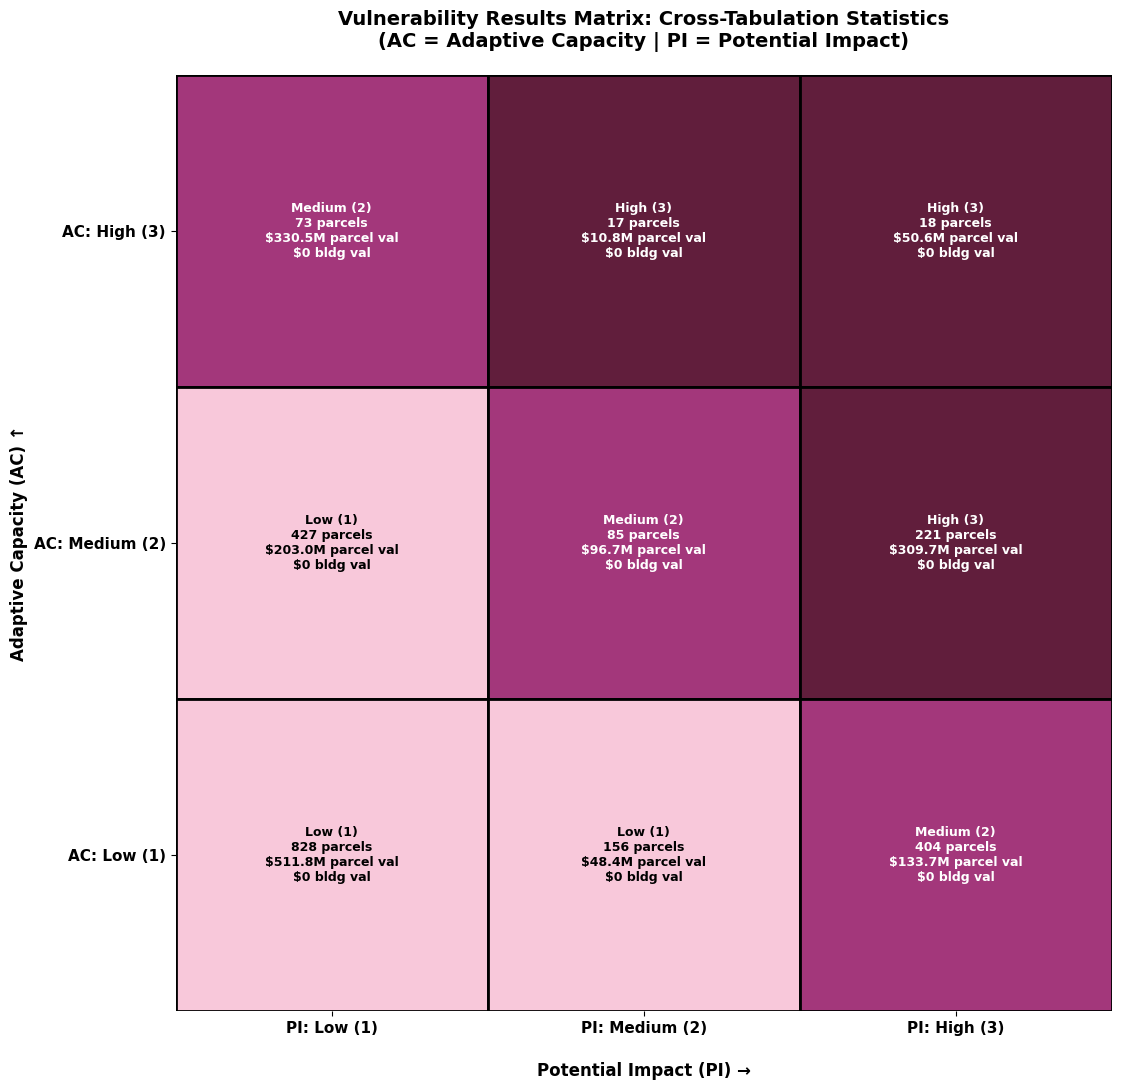

✓ Vulnerability Results Matrix visualization complete!


In [18]:
# Helper function to format dollar values
def format_currency(value):
    """Format a value as currency with appropriate scale (M, K, or plain)"""
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    elif value >= 1_000:
        return f'${value / 1_000:.1f}K'
    else:
        return f'${int(value)}'

# Define the vulnerability lookup and label mappings using official symbology
# Vulnerability: 1 (Low)=#F8C8DA, 2 (Medium)=#A3377B, 3 (High)=#611E3C
vuln_lookup_matrix = {
    (1, 1): 2,  # Low AC, Low PI → Medium vulnerability
    (1, 2): 3,  # Low AC, Medium PI → High vulnerability
    (1, 3): 3,  # Low AC, High PI → High vulnerability
    (2, 1): 1,  # Medium AC, Low PI → Low vulnerability
    (2, 2): 2,  # Medium AC, Medium PI → Medium vulnerability
    (2, 3): 3,  # Medium AC, High PI → High vulnerability
    (3, 1): 1,  # High AC, Low PI → Low vulnerability
    (3, 2): 1,  # High AC, Medium PI → Low vulnerability
    (3, 3): 2,  # High AC, High PI → Medium vulnerability
}

vuln_labels = {1: 'Low', 2: 'Medium', 3: 'High'}

# Build the results matrix data structure
# matrix_data[ac_index][pi_index] will contain the statistics for that cell
matrix_data = {}

# Check which value fields exist in the data
has_parval = 'parval' in parcels.columns
has_improvval = 'landval' in parcels.columns
parcels['structure_value'] = parcels['parval'] - parcels['landval']

if not has_parval:
    print("Note: 'parval' column not found. Using 0 for parcel values.")
if not has_improvval:
    print("Note: 'landval' column not found. Using 0 for building values.")

# Calculate statistics for each cell in the matrix
for ac in [1, 2, 3]:
    for pi in [1, 2, 3]:
        # Filter parcels matching this AC-PI combination
        mask = (parcels['adaptive_capacity'] == ac) & (parcels['potential_impact'] == pi)
        subset = parcels[mask]
        
        # Count parcels
        count = len(subset)
        
        # Get parcel value
        parval_sum = subset['parval'].sum() if has_parval else 0
        
        # Get improvement value
        improvval_sum = subset['structure_value'].sum() if has_improvval else 0
        
        # Get vulnerability score for this AC-PI combination
        vuln_score = vuln_lookup_matrix.get((ac, pi), 0)
        vuln_label = vuln_labels.get(vuln_score, 'Unknown')
        
        # Store in the matrix structure
        matrix_data[(ac, pi)] = {
            'score': vuln_score,
            'score_label': vuln_label,
            'count': count,
            'parval': parval_sum,
            'improvval': improvval_sum
        }

# Color mapping for vulnerability scores using official symbology
colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}
text_colors = {1: 'black', 2: 'white', 3: 'white'}

# Create the visualization
fig, ax = plt.subplots(figsize=(14, 11))

# Draw the matrix cells
ac_labels = ['Low (1)', 'Medium (2)', 'High (3)']
pi_labels = ['Low (1)', 'Medium (2)', 'High (3)']

for i, ac in enumerate([1, 2, 3]):
    for j, pi in enumerate([1, 2, 3]):
        # Get data for this cell
        data = matrix_data.get((ac, pi), {})
        vuln_score = data.get('score', 0)
        vuln_label = data.get('score_label', 'Unknown')
        count = data.get('count', 0)
        parval = data.get('parval', 0)
        improvval = data.get('structure_value', 0)
        
        # Get background color based on vulnerability score
        bg_color = colors.get(vuln_score, '#FFFFFF')
        text_color = text_colors.get(vuln_score, 'black')
        
        # Draw the cell rectangle
        # Flip row index so Low AC is at top (i=0 corresponds to ac=1)
        cell_y = 2 - i
        ax.add_patch(plt.Rectangle((j, cell_y), 1, 1, facecolor=bg_color, 
                                   edgecolor='black', linewidth=2))
        
        # Build the cell text content
        # Line 1: Vulnerability score label
        line1 = f'{vuln_label} ({vuln_score})'
        
        # Line 2: Count of parcels
        line2 = f'{count} parcels'
        
        # Line 3: Parcel value
        parval_str = format_currency(parval)
        line3 = f'{parval_str} parcel val'
        
        # Line 4: Building value
        improvval_str = format_currency(improvval)
        line4 = f'{improvval_str} bldg val'
        
        # Combine all lines
        cell_text = f'{line1}\n{line2}\n{line3}\n{line4}'
        
        # Add text to the cell
        ax.text(j + 0.5, cell_y + 0.5, cell_text, ha='center', va='center',
                fontsize=9, fontweight='bold', color=text_color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='none', edgecolor='none'))

# Set axis properties
ax.set_xlim(0, 3)
ax.set_ylim(0, 3)
ax.set_aspect('equal')

# Set tick labels for columns (Potential Impact)
ax.set_xticks([0.5, 1.5, 2.5])
ax.set_xticklabels(['PI: Low (1)', 'PI: Medium (2)', 'PI: High (3)'], 
                   fontsize=11, fontweight='bold')

# Set tick labels for rows (Adaptive Capacity - reversed so Low is at top)
ax.set_yticks([0.5, 1.5, 2.5])
ax.set_yticklabels(['AC: Low (1)', 'AC: Medium (2)', 'AC: High (3)'], 
                   fontsize=11, fontweight='bold')

# Add axis labels
ax.set_xlabel('\nPotential Impact (PI) →', fontsize=12, fontweight='bold')
ax.set_ylabel('Adaptive Capacity (AC) ↑', fontsize=12, fontweight='bold')

# Add title and subtitle
ax.set_title('Vulnerability Results Matrix: Cross-Tabulation Statistics\n' + 
             '(AC = Adaptive Capacity | PI = Potential Impact)',
             fontsize=14, fontweight='bold', pad=20)

# Remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

plt.tight_layout()
plt.show()

print('✓ Vulnerability Results Matrix visualization complete!')

## Step 5: Analyze Vulnerability Results

Let's understand the distribution of vulnerability across your parcels.

In [13]:
# Calculate statistics
vuln_stats = parcels['vulnerability'].value_counts().sort_index()
total_parcels = len(parcels)

print("=" * 60)
print("VULNERABILITY DISTRIBUTION")
print("=" * 60)

vuln_labels = {1: 'Low', 2: 'Medium', 3: 'High'}

for vuln_level in [1, 2, 3]:
    count = vuln_stats.get(vuln_level, 0)
    percentage = (count / total_parcels) * 100
    label = vuln_labels.get(vuln_level, 'Unknown')
    print(f"\nVulnerability = {vuln_level} ({label:6s})")
    print(f"  Count:      {count} parcels")
    print(f"  Percentage: {percentage:.1f}%")

print(f"\nTotal parcels: {total_parcels}")
print("=" * 60)

VULNERABILITY DISTRIBUTION

Vulnerability = 1 (Low   )
  Count:      1411 parcels
  Percentage: 8.8%

Vulnerability = 2 (Medium)
  Count:      562 parcels
  Percentage: 3.5%

Vulnerability = 3 (High  )
  Count:      256 parcels
  Percentage: 1.6%

Total parcels: 16078


### Chart: Vulnerability Distribution

A bar chart showing how many parcels fall into each vulnerability category.

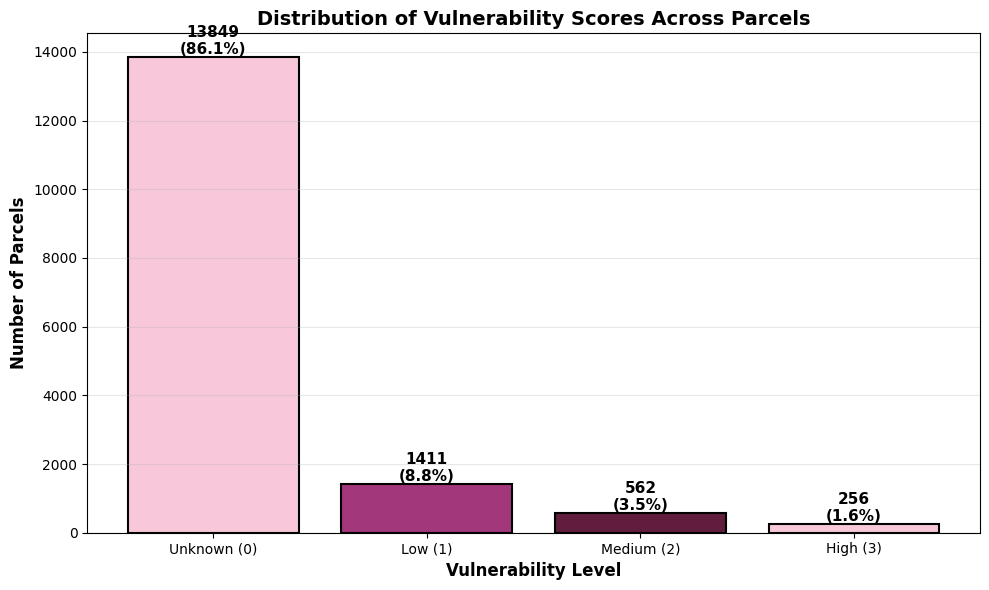

In [14]:
# Create a bar chart of vulnerability distribution
fig, ax = plt.subplots(figsize=(10, 6))

vuln_counts = parcels['vulnerability'].value_counts().sort_index()
colors_bar = ['#F8C8DA', '#A3377B', '#611E3C']  # Pink, magenta, burgundy
labels_bar = {1: 'Low (1)', 2: 'Medium (2)', 3: 'High (3)'}

bars = ax.bar(range(len(vuln_counts)), vuln_counts.values, color=colors_bar[:len(vuln_counts)],
              edgecolor='black', linewidth=1.5)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    percentage = (height / len(parcels)) * 100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Vulnerability Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Parcels', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Vulnerability Scores Across Parcels', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(vuln_counts)))
ax.set_xticklabels([labels_bar.get(idx, f'Unknown ({idx})') for idx in vuln_counts.index])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Step 6: Map Your Vulnerability Results

An interactive map showing vulnerability scores across your study area. Click on parcels to see their details.

**Color Key:**
- Green = Low (1)
- Yellow = Medium (2)
- Red = High (3)
- Gray = Not scored

In [15]:
from IPython.display import HTML

# Check if parcels have geometry
if parcels.crs is None:
    print("⚠ Warning: Parcels have no CRS (coordinate reference system)")

if 'geometry' not in parcels.columns:
    print("⚠ Warning: Parcels have no geometry column")
else:
    # Reproject to WGS84 (EPSG:4326) for Folium compatibility
    if parcels.crs != 'EPSG:4326':
        parcels_wgs84 = parcels.to_crs('EPSG:4326')
    else:
        parcels_wgs84 = parcels.copy()

    # Calculate map center
    bounds = parcels_wgs84.total_bounds
    center_lat = (bounds[1] + bounds[3]) / 2
    center_lon = (bounds[0] + bounds[2]) / 2

    # Create base map with dark basemap
    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles='https://{s}.basemaps.cartocdn.com/dark_all/{z}/{x}/{y}{r}.png',
        attr='CartoDB',
        width='100%',
        height='450px'
    )

    # Color mapping for vulnerability using official symbology
    # Vulnerability: 1 (Low)=#F8C8DA, 2 (Medium)=#A3377B, 3 (High)=#611E3C
    vuln_colors = {
        1: '#F8C8DA',      # Light pink for Low
        2: '#A3377B',      # Magenta for Medium
        3: '#611E3C',      # Dark burgundy for High
        0: '#555555'       # Gray for Not scored
    }

    vuln_names = {
        1: 'Low',
        2: 'Medium',
        3: 'High',
        0: 'Not Scored'
    }

    # Add parcels to map
    for idx, row in parcels_wgs84.iterrows():
        geom = row['geometry']
        vuln = row['vulnerability']
        color = vuln_colors.get(vuln, '#555555')

        # Build popup text
        popup_text = f"""
        <b>Parcel {idx}</b><br>
        Vulnerability: <b>{vuln_names.get(vuln, 'Unknown')}</b><br>
        Adaptive Capacity: {row.get('adaptive_capacity', 'N/A')}<br>
        Potential Impact: {row.get('potential_impact', 'N/A')}
        """

        if geom.geom_type == 'Polygon':
            folium.GeoJson(
                data=geom.__geo_interface__,
                style_function=lambda x, c=color: {
                    'fillColor': c,
                    'color': '#00e5ff',
                    'weight': 1,
                    'fillOpacity': 0.7
                },
                popup=folium.Popup(popup_text, max_width=300)
            ).add_to(m)

    # Add legend
    legend_html = '''
    <div style="position: fixed;
                bottom: 50px; right: 50px; width: 220px; height: 200px;
                background-color: #2b2b2b; border:2px solid #00e5ff; z-index:9999;
                font-size:14px; padding: 10px; color: white">
    <p style="margin: 0 0 10px 0; font-weight: bold;">Vulnerability Legend</p>
    <p style="margin: 5px;"><i style="background:#F8C8DA; width:18px; height:18px; float:left; margin-right:8px; border: 1px solid #00e5ff;"></i>Low (1)</p>
    <p style="margin: 5px;"><i style="background:#A3377B; width:18px; height:18px; float:left; margin-right:8px; border: 1px solid #00e5ff;"></i>Medium (2)</p>
    <p style="margin: 5px;"><i style="background:#611E3C; width:18px; height:18px; float:left; margin-right:8px; border: 1px solid #00e5ff;"></i>High (3)</p>
    <p style="margin: 5px;"><i style="background:#555555; width:18px; height:18px; float:left; margin-right:8px; border: 1px solid #00e5ff;"></i>Not Scored</p>
    </div>
    '''
    m.get_root().html.add_child(folium.Element(legend_html))

    # Display map with HTML wrapper
    map_html = m._repr_html_()
    display(HTML(f'<div style="height:450px;overflow:hidden;">{map_html}</div>'))

## Export Vulnerability Map to PNG

We'll create a high-resolution PNG map showing the vulnerability assessment with all layers properly styled and ordered.

✓ Buildings loaded: 22222 features
✓ Flood zones loaded: 233 features
  Categories: {'100-year': 109, '500-year': 108, 'Floodway': 16}


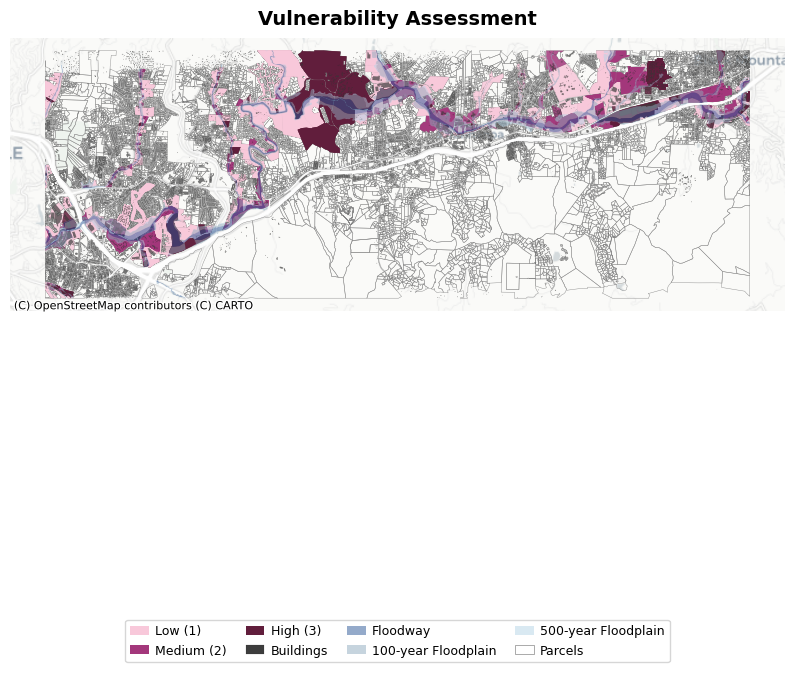

✓ Map exported to: ./outputs/vulnerability_map.png


In [16]:
import contextily as ctx
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

# Reproject to Web Mercator for basemap tiles
parcels_wm = parcels.to_crs(epsg=3857)

# Create figure with map panel + legend panel below
fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(2, 1, height_ratios=[10, 1.2], hspace=0.02)
ax = fig.add_subplot(gs[0])
ax_legend = fig.add_subplot(gs[1])

# Layer 1 (bottom): All parcels - no fill, thin grey borders
parcels_wm.plot(ax=ax, facecolor='none', edgecolor='#888888', linewidth=0.3)

# Layer 2: Vulnerability layer - score 0 NOT plotted
# Color mapping for vulnerability using official symbology
# Vulnerability: 1 (Low)=#F8C8DA, 2 (Medium)=#A3377B, 3 (High)=#611E3C
vuln_colors = {1: '#F8C8DA', 2: '#A3377B', 3: '#611E3C'}
for score in [1, 2, 3]:
    subset = parcels_wm[parcels_wm['vulnerability'] == score]
    if len(subset) > 0:
        subset.plot(ax=ax, facecolor=vuln_colors[score], edgecolor='none', alpha=0.85)

# Layer 3: Buildings
try:
    buildings_layer = gpd.read_file(CLASS0_GPKG, layer='buildings')
    buildings_wm = buildings_layer.to_crs(epsg=3857)
    buildings_wm.plot(ax=ax, facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, alpha=0.7)
    print(f"✓ Buildings loaded: {len(buildings_layer)} features")
except Exception as e:
    print(f"⚠ Could not load buildings: {e}")

# Layer 4: Flood zones with transparency (all three categories)
try:
    flood_zones_full = gpd.read_file(CLASS0_GPKG, layer='flood_zones')
    flood_wm = flood_zones_full.to_crs(epsg=3857)
    flood_colors = {'Floodway': '#2B5797', '100-year': '#8FABBE', '500-year': '#B4D4E7'}
    for flood_type in ['500-year', '100-year', 'Floodway']:
        flood_subset = flood_wm[flood_wm['flood_category'] == flood_type]
        if len(flood_subset) > 0:
            flood_subset.plot(ax=ax, facecolor=flood_colors.get(flood_type, '#B4D4E7'),
                            edgecolor='none', alpha=0.5)
    print(f"✓ Flood zones loaded: {len(flood_zones_full)} features")
    print(f"  Categories: {flood_zones_full['flood_category'].value_counts().to_dict()}")
except Exception as e:
    print(f"⚠ Could not load flood zones: {e}")

# Add CartoDB Positron (light) basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom='auto')

# Style the map panel
ax.set_axis_off()
ax.set_title('Vulnerability Assessment', fontsize=14, fontweight='bold', pad=10)

# Build legend in bottom panel
ax_legend.set_axis_off()
legend_elements = [
    Patch(facecolor='#F8C8DA', edgecolor='none', label='Low (1)'),
    Patch(facecolor='#A3377B', edgecolor='none', label='Medium (2)'),
    Patch(facecolor='#611E3C', edgecolor='none', label='High (3)'),
    Patch(facecolor='#3D3D3D', edgecolor='#2a2a2a', linewidth=0.1, label='Buildings'),
    Patch(facecolor='#2B5797', edgecolor='none', alpha=0.5, label='Floodway'),
    Patch(facecolor='#8FABBE', edgecolor='none', alpha=0.5, label='100-year Floodplain'),
    Patch(facecolor='#B4D4E7', edgecolor='none', alpha=0.5, label='500-year Floodplain'),
    Patch(facecolor='none', edgecolor='#888888', linewidth=0.5, label='Parcels'),
]
ax_legend.legend(handles=legend_elements, loc='center', ncol=4, fontsize=9,
                frameon=True, facecolor='white', edgecolor='#cccccc',
                handlelength=1.5, handletextpad=0.5, columnspacing=1.5)

# Export
# Ensure OUTPUT_DIR is defined and created
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
png_path = os.path.join(OUTPUT_DIR, 'vulnerability_map.png')
plt.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.show()
print(f"✓ Map exported to: {png_path}")

## Step 7: Save Your Vulnerability Results

We'll save the updated parcels layer (with the new vulnerability column) back to the GeoPackage.

In [17]:
try:
    import fiona
    import sqlite3
    
    # Save parcels layer first (creates new GeoPackage)
    parcels.to_file(OUTPUT_GPKG, layer='parcels', driver='GPKG', mode='w')
    print(f"✓ Saved parcels layer with vulnerability ({len(parcels)} features)")
    
    # Copy forward all other layers from the input GeoPackage
    if os.path.exists(INPUT_GPKG):
        input_layers = fiona.listlayers(INPUT_GPKG)
        for layer_name in input_layers:
            if layer_name == 'parcels':
                continue  # Already saved updated version
            try:
                layer_data = gpd.read_file(INPUT_GPKG, layer=layer_name)
                layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                print(f"✓ Copied layer: {layer_name} ({len(layer_data)} features)")
            except Exception as e:
                print(f"  Note: Could not copy layer '{layer_name}' as spatial: {e}")
        
        # Also copy any non-spatial tables (like 'summary') via sqlite3
        try:
            conn_in = sqlite3.connect(INPUT_GPKG)
            conn_out = sqlite3.connect(OUTPUT_GPKG)
            cursor = conn_in.cursor()
            # Get all tables that aren't in fiona's layer list and aren't system tables
            cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
            all_tables = [row[0] for row in cursor.fetchall()]
            system_tables = ['gpkg_contents', 'gpkg_geometry_columns', 'gpkg_spatial_ref_sys',
                            'gpkg_ogr_contents', 'gpkg_tile_matrix', 'gpkg_tile_matrix_set',
                            'sqlite_sequence', 'gpkg_extensions', 'gpkg_metadata',
                            'gpkg_metadata_reference']
            for table in all_tables:
                if table in system_tables or table in input_layers or table.startswith('rtree_') or table.startswith('trigger_'):
                    continue
                try:
                    df = pd.read_sql(f'SELECT * FROM "{table}"', conn_in)
                    if len(df) > 0:
                        df.to_sql(table, conn_out, if_exists='replace', index=False)
                        print(f"✓ Copied non-spatial table: {table} ({len(df)} rows)")
                except Exception:
                    pass
            conn_in.close()
            conn_out.close()
        except Exception:
            pass
    
    # Also ensure base layers from Class 0 are included (flood_zones, buildings, study_area)
    # These may not be in INPUT_GPKG if earlier classes didn't carry them forward
    if os.path.exists(CLASS0_GPKG):
        try:
            import fiona as _fiona
            # Get layers already written to output
            output_layers = _fiona.listlayers(OUTPUT_GPKG)
            # Get layers available in Class 0
            class0_layers = _fiona.listlayers(CLASS0_GPKG)
            # Copy any missing layers
            for layer_name in class0_layers:
                if layer_name not in output_layers:
                    try:
                        layer_data = gpd.read_file(CLASS0_GPKG, layer=layer_name)
                        layer_data.to_file(OUTPUT_GPKG, layer=layer_name, driver='GPKG', mode='a')
                        print(f"✓ Added base layer from Class 0: {layer_name} ({len(layer_data)} features)")
                    except Exception as e:
                        print(f"  Note: Could not copy base layer '{layer_name}': {e}")
        except Exception:
            pass
    
    print(f"\n✓ All data saved to: {OUTPUT_GPKG}")
except Exception as e:
    print(f"✗ Error saving to GeoPackage: {e}")
    print("\nAlternative: Save to a new GeoPackage file")
    alt_path = os.path.join(DATA_DIR, 'class_4_vulnerability_backup.gpkg')
    parcels.to_file(alt_path, layer='parcels', driver='GPKG')
    print(f"✓ Saved to: {alt_path}")

✓ Saved parcels layer with vulnerability (16078 features)
✓ Copied layer: flood_zones_100yr (1250 features)
✓ Copied layer: study_area (5 features)
✓ Copied layer: flood_zones (1165 features)
✓ Copied layer: buildings (111110 features)

✓ All data saved to: ./data/class_4_vulnerability.gpkg


## Color Reference for GIS Symbology

Use these hex color values when styling your vulnerability layer in QGIS or ArcGIS Pro:

| Score | Label | Hex Code | RGB |
|-------|-------|----------|-----|
| 1 | Low | `#F8C8DA` | 248, 200, 218 |
| 2 | Medium | `#A3377B` | 163, 55, 123 |
| 3 | High | `#611E3C` | 97, 30, 60 |

**How to apply in QGIS:**
1. Right-click your layer → Properties → Symbology
2. Choose "Categorized" from the dropdown
3. Set Column to `vulnerability`
4. Click "Classify"
5. Double-click each symbol to change its color using the hex values above

**How to apply in ArcGIS Pro:**
1. Right-click your layer → Symbology
2. Choose "Unique Values"
3. Set Field 1 to `vulnerability`
4. Click "Add all values"
5. Double-click each symbol to change its color using the hex values above

**Pre-made symbology files** are also available in the `symbology/` folder:
- `vulnerability_symbology.qml` — Load in QGIS via Style → Load Style
- `vulnerability_symbology.lyrx` — Import in ArcGIS Pro via Symbology → Import


## How to Do This in QGIS

If you prefer to use QGIS instead of Python, you can create the vulnerability field using a QGIS expression.

### Steps in QGIS:
1. Open the parcels layer in QGIS
2. Go to **Layer → Fields** (or right-click on layer → Edit)
3. Click the **+** button to add a new field
4. Name: `vulnerability` | Type: `Integer` | Click **OK**
5. Go back to the layer, right-click on the new `vulnerability` field header
6. Select **Edit → Field Calculator** (or double-click the field)
7. Paste the expression below into the calculator
8. Click **OK**

### QGIS Expression:
```sql
CASE
  WHEN "adaptive_capacity" = 1 AND "potential_impact" = 1 THEN 2
  WHEN "adaptive_capacity" = 1 AND "potential_impact" = 2 THEN 3
  WHEN "adaptive_capacity" = 1 AND "potential_impact" = 3 THEN 3
  WHEN "adaptive_capacity" = 2 AND "potential_impact" = 1 THEN 1
  WHEN "adaptive_capacity" = 2 AND "potential_impact" = 2 THEN 2
  WHEN "adaptive_capacity" = 2 AND "potential_impact" = 3 THEN 3
  WHEN "adaptive_capacity" = 3 AND "potential_impact" = 1 THEN 1
  WHEN "adaptive_capacity" = 3 AND "potential_impact" = 2 THEN 1
  WHEN "adaptive_capacity" = 3 AND "potential_impact" = 3 THEN 2
  ELSE 0
END
```

### To Visualize in QGIS:
1. Right-click the vulnerability field → **Symbology**
2. Use **Categorized** or **Rule-based** styling
3. Assign colors: Green (1), Yellow (2), Red (3)

## How to Do This in ArcGIS Pro

If you prefer ArcGIS Pro, follow these steps:

### Steps in ArcGIS Pro:
1. Open the parcels feature class
2. Go to **Table Design** (or click the Data tab)
3. Click **New Field**
4. Name: `vulnerability` | Type: `Short Integer` | Click **OK**
5. Right-click on the new `vulnerability` field
6. Click **Calculate Field**
7. Set the **Expression Type** to `Python`
8. Paste the code below into the expression box
9. Click **OK**

### ArcGIS Python Expression:

Define the function in the **Code Block:**
```python
def calc_vulnerability(ac, pi):
    matrix = {
        (1, 1): 2, (1, 2): 3, (1, 3): 3,
        (2, 1): 1, (2, 2): 2, (2, 3): 3,
        (3, 1): 1, (3, 2): 1, (3, 3): 2,
    }
    return matrix.get((ac, pi), 0)
```

Then use this **Expression:**
```
calc_vulnerability(!adaptive_capacity!, !potential_impact!)
```

### To Visualize in ArcGIS Pro:
1. Right-click the layer in the Contents pane
2. Go to **Symbology**
3. Choose **Categorized** values
4. Field: `vulnerability`
5. Assign colors: Green (1), Yellow (2), Red (3)

## Summary

In this class, you:
1. ✓ Learned what **Vulnerability** means: how susceptible something is to harm
2. ✓ Understood the **Vulnerability Scoring Matrix**: a lookup table combining Adaptive Capacity and Potential Impact
3. ✓ Applied the matrix to your parcel data using Python
4. ✓ Mapped vulnerability results across your study area
5. ✓ Saved your results back to the GeoPackage

## Key Takeaways

- **Vulnerability is NOT just about hazard impact.** Adaptive capacity (preparedness, resources) matters equally.
- **The matrix approach is flexible.** Different studies may use different matrices based on local context.
- **High adaptive capacity can offset high potential impact.** A well-prepared community is more resilient.

## Next Steps

In **Class 5**, we'll combine Vulnerability + Exposure to calculate **Risk** and determine which parcels are at the highest risk.

## Questions?

If anything is unclear, review the matrix visualization and the examples. The vulnerability concept is foundational to all risk assessment work!